# IMT 574 Final Project Notebook
- WIN 2025, 3/18/2025
- Contributors: Em Stelter, Ivette Ivanov, Julia Zhu

# Introduction to the Dataset

### Question 1: Describe the dataset you chose. Why did you choose it? What features does it include? What year is it from? How was it collected? What should we know about this dataset as we read your write-up? (8pts)

We chose a dataset from the University of California Irvine Machine Learning Repository that collected information from direct telemarketing campaigns of a Portuguese banking institution from May 2008 to November 2010 (Moro et al).

[Bank Marketing - UCI Machine Learning Repository
](https://archive.ics.uci.edu/dataset/222/bank+marketing)

The general predictor variable within this dataset is written as a binary outcome: yes or no, whether the client would subscribe to a bank term deposit. Investopedia, a website focused on providing general information and definitions about the specifics of financial services and institutions describes a term deposit as when a customer, “will deposit or invest in one of these accounts, agreeing not to withdraw their funds for a fixed period in return for a higher rate of interest paid on the account" (Investopedia).

There are 16 features within this dataset, including the following categories (Moro et al):

**Demographic information of customers:**
- Age
- Occupation
- Marital status
- Highest attained education level

**Information related to customers' current accounts:**
- Whether the client has credit in default
- Average yearly balance
- Whether the client has a housing loan
- Whether the client has a personal loan

**Additional information regarding the call itself:**
- Contact communication type (cellular vs a landline telephone)
- The day of the week that the client was contacted
- Duration of the phone call
- Number of times this client was contacted for this campaign
- Number of days that passed by after the client was last contacted from a previous campaign
- Number of contacts performed before this campaign and for this client
- The outcome of the previous campaign

**Response variable we are interested in investigating:**
- Has the client subscribed to a term deposit?

# Research Question

### Question 2: Define a research question. What are you trying to predict? Describe what you’re trying to accomplish (it will differ between Supervised and Unsupervised learning). (4pts)

**What factors determine whether bank customers will subscribe to a term deposit in response to a telemarketing campaign?**

The marketing campaigns were based on phone calls. Often, more than one contact with the same client was required to ensure that said client would agree to subscribe to a term deposit. We are interested in developing a model that can take these different features into account in order to best optimize future telemarketing campaigns.

**In other words, the classification goal is to predict if the client will subscribe (yes/no) to a term deposit (variable y).**

# Choice of Algorithm

### Question 3: Why is this algorithm a good way of answering your research question? (4pts)

We needed to use models that would estimate binary outcomes for classification, so around 5 general categories of models were used in order to answer the research question.

In the context of a marketing campaign, recall was determined to be the most relevant performance metric for each model. Since our goal is to increase subscriptions to term deposits, discovering the number of true positives is more significant than the number of true negatives via precision (although we also looked at the precision scores).

Initially, we attempted to answer this research question with various algorithms that ultimately were not the most effective:

* **Logistic Regression:** Multiple attempts were made with logistic regression, none of them had a recall that was higher than 38%. Our assumption was that this particular data set didn’t have a linear distribution.
* **K-nearest neighbors:** We simply did not find any truly significant results with K-nn. It’s likely that the dataset used is rather noisy. Especially as there was a huge class imbalance between the number of positive observations in the data set (approx. 4000) and the number of negative observations (approx. 30,000).
* **Gradient Boosted Decision Trees:** Similarly, it’s likely that this class imbalance impacted our attempt at gradient boosting since the majority class of negative observations (or people who did not subscribe to the term deposit) seemed to be favored.

However, with certain alterations, we found that both decision trees and a random forest could be used as effective models for this data set:

* **Decision Tree:** (Decision Tree with Lower Decision Threshold, Undersampling & Synthetic Sampling): Seen in Appendix B
* **Random Forest:** Finally, random forest produced the highest recall for this dataset since we used a grid search. We assume that it is also a result of the ensemble method better handling the class imbalance compared to the individual decision trees.

### Question 4: Using the data you chose and the algorithm you chose, read in your data and run your model. (10pts)

#### Data Cleaning

In [ ]:
# From: https://archive.ics.uci.edu/dataset/222/bank+marketing
# pip install ucimlrepo

!pip install ucimlrepo

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

In [ ]:
# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [ ]:
bank_full = pd.read_csv('/content/drive/MyDrive/Coursework 2025 WIN/IMT 574/Assignments/bank+marketing/bank/bank-full.csv', sep = ';')
print(bank_full.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Coursework 2025 WIN/IMT 574/Assignments/bank+marketing/bank/bank-full.csv'

In [ ]:
# Identify unique labels in categorical columns
for column in list(bank_full.columns):
  unique_values= bank_full[str(column)].unique()
  print('Unique values in ' + str(column) + ':' + str(unique_values))

Unique values in age:[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
Unique values in job:['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Unique values in marital:['married' 'single' 'divorced']
Unique values in education:['tertiary' 'secondary' 'unknown' 'primary']
Unique values in default:['no' 'yes']
Unique values in balance:[ 2143    29     2 ...  8205 14204 16353]
Unique values in housing:['yes' 'no']
Unique values in loan:['no' 'yes']
Unique values in contact:['unknown' 'cellular' 'telephone']
Unique values in day:[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
Unique values in month:['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr

In [ ]:
# Convert categorical variables with integers
bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
                          'management', 'retired', 'self-employed', 'services',
                          'student', 'technician', 'unemployed', 'unknown'],
                           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['marital'].replace(['single', 'married', 'divorced'],[1, 2, 3], inplace=True)
bank_full['education'].replace(['tertiary', 'secondary', 'unknown', 'primary'],[3, 2, 0, 1], inplace=True)
bank_full['default'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['housing'].replace(['yes', 'no'], [1, 0], inplace=True)
bank_full['loan'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['contact'].replace(['unknown', 'cellular', 'telephone'], [0, 1, 2], inplace=True)
bank_full['month'].replace(['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['poutcome'].replace(['unknown', 'failure', 'other', 'success'], [2, 0, 3, 1], inplace=True)
bank_full['y'].replace(['no', 'yes'], [0, 1], inplace=True)

<ipython-input-11-b8edec95c237>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
<ipython-input-11-b8edec95c237>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bank_full['job'].replace(['admin.', 'blue-collar', 'entrep

In [ ]:
# define features and targets dataframes
X_bank_full = bank_full[['age','job','marital','education','default','balance','housing','loan','contact','day','month','duration','campaign','pdays','previous','poutcome']]
y_bank_full = bank_full[['y']]

print(X_bank_full.head())
print(y_bank_full.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    5        2          3        0     2143        1     0        0   
1   44   10        1          2        0       29        1     0        0   
2   33    3        2          2        0        2        1     1        0   
3   47    2        2          0        0     1506        1     0        0   
4   33   12        1          0        0        1        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  
0    5      5       261         1     -1         0         2  
1    5      5       151         1     -1         0         2  
2    5      5        76         1     -1         0         2  
3    5      5        92         1     -1         0         2  
4    5      5       198         1     -1         0         2  
   y
0  0
1  0
2  0
3  0
4  0


#### Initial Random Forest Model

Steps for implementing the random forest model:
* Separate dataset into features and targets (above)
* Split into test set and training set
* Determine if feature selection is needed (we used a kitchen sink method for Random Forest and selected specific features based on exploratory data analysis for the Decision Tree)
* Train and fit random forest model
* Run predictions for random forest model
* Calculate recall score for random forest model
* Make hyperparameter adjustments with grid search and lowered probability threshold to account for imbalanced positive/negative classes
* Refit model with adjusted parameters
* Calculate new recall score

In [ ]:
# Divide dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_bank_full, y_bank_full, test_size=0.33, random_state=42, stratify=y)

# Note: we received feedback to adjust the test size to 20%; this change is reflected in the updated random forest model below

In [ ]:
# Fit initial random forest model
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators = 100, max_depth = 30, min_samples_split=15, criterion = 'gini')
random_forest_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=30, min_samples_split=15)

In [ ]:
# Run predictions for random forest model
y_pred_forest = random_forest_model.predict(X_test)
# print(y_pred_forest)

In [ ]:
# View classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     13175
           1       0.66      0.40      0.50      1745

    accuracy                           0.91     14920
   macro avg       0.79      0.69      0.73     14920
weighted avg       0.89      0.91      0.90     14920



Without a systematic approach for deciding parameters, we achieved an initial recall score of 39% for predicting the positive class / customers who would select a term deposit

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


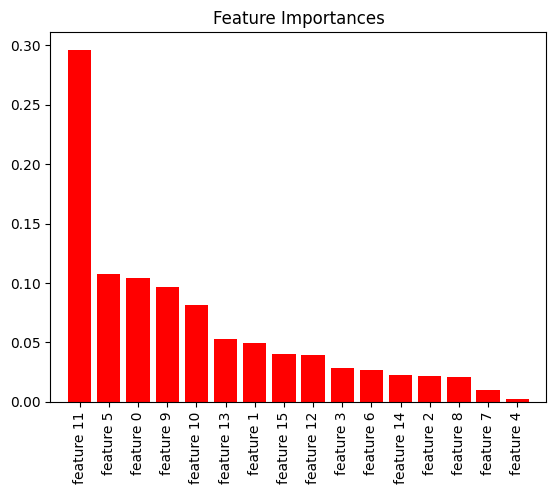

In [ ]:
# For reference - determine feature importances and plot most used features
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

feature_names = [f"feature {i}" for i in range(X_bank_full.shape[1])]
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

# Feature Importance
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature Importances")
plt.bar(range(X_bank_full.shape[1]), importances[indices], color="r", align="center")
plt.xticks(range(X_bank_full.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

The five most important features as determined by this method were:
* Feature 11: Duration
* Feature 5: Balance
* Feature 0: Age
* Feature 9: Day of week
* Feature 10: Month

This is a slightly different group of features from the features we selected for the Decision Tree model via Exploratory Data Analysis. However, given feedback that these feature importances were impacted by random forest sampling, we stuck with the original features identified by EDA for the Decision Tree model.

In [ ]:
# variable information
print(bank_marketing.variables)

           name     role         type      demographic  \
0           age  Feature      Integer              Age   
1           job  Feature  Categorical       Occupation   
2       marital  Feature  Categorical   Marital Status   
3     education  Feature  Categorical  Education Level   
4       default  Feature       Binary             None   
5       balance  Feature      Integer             None   
6       housing  Feature       Binary             None   
7          loan  Feature       Binary             None   
8       contact  Feature  Categorical             None   
9   day_of_week  Feature         Date             None   
10        month  Feature         Date             None   
11     duration  Feature      Integer             None   
12     campaign  Feature      Integer             None   
13        pdays  Feature      Integer             None   
14     previous  Feature      Integer             None   
15     poutcome  Feature  Categorical             None   
16            

### Question 5: Conduct a hyperparameter sensitivity analysis by systematically varying key model parameters and measuring their impact on model performance. You only need to do this for one hyperparameter if your selected algorithm has multiple. (6pts)

#### Random Forest V6: with Grid Search Parameters and Adjusted Probability Threshold

In [ ]:
# Divide dataset into training and test sets -- adjusting to 20% test set
from sklearn.model_selection import train_test_split
X_train_V2, X_test_V2, y_train_V2, y_test_V2 = train_test_split(X_bank_full, y_bank_full, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# Fit random forest model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state=42)
rf_model.fit(X_train_V2, y_train_V2)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [ ]:
# Conduct grid search
from sklearn.model_selection import GridSearchCV
parameters = {'max_depth':list(range(1,30,2)), 'min_samples_split':list(range(2,30,2))}
rf_model_V2 = GridSearchCV(rf_model, param_grid=parameters, scoring='recall')
rf_model_V2.fit(X_train_V2, y_train_V2)
sorted(rf_model_V2.cv_results_.keys())

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'param_max_depth',
 'param_min_samples_split',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score']

In [ ]:
# Convert gridsearch results to dataframe
rf_gridsearch_results = pd.DataFrame(rf_model_V2.cv_results_)

In [ ]:
# Display gridsearch results
from IPython.display import display
import pandas as pd
display(rf_gridsearch_results)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.446722,0.582895,0.046668,0.006117,1,2,"{'max_depth': 1, 'min_samples_split': 2}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
1,1.525488,0.356340,0.043457,0.008343,1,4,"{'max_depth': 1, 'min_samples_split': 4}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
2,1.648501,0.509987,0.103030,0.023744,1,6,"{'max_depth': 1, 'min_samples_split': 6}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
3,1.119015,0.290413,0.041607,0.012946,1,8,"{'max_depth': 1, 'min_samples_split': 8}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
4,0.779869,0.075913,0.032381,0.008104,1,10,"{'max_depth': 1, 'min_samples_split': 10}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,4.109047,0.384772,0.110980,0.007236,29,20,"{'max_depth': 29, 'min_samples_split': 20}",0.401891,0.374704,0.369540,0.411348,0.408983,0.393293,0.017640,78
206,4.079005,0.438449,0.113729,0.018072,29,22,"{'max_depth': 29, 'min_samples_split': 22}",0.401891,0.388889,0.378985,0.418440,0.416076,0.400856,0.015254,50
207,4.106587,0.377735,0.109981,0.010095,29,24,"{'max_depth': 29, 'min_samples_split': 24}",0.379433,0.371158,0.381346,0.425532,0.411348,0.393763,0.020924,76
208,3.985514,0.351397,0.110839,0.016295,29,26,"{'max_depth': 29, 'min_samples_split': 26}",0.386525,0.365248,0.371901,0.401891,0.416076,0.388328,0.018760,93


In [ ]:
# Print gridsearch result with best mean recall score
print(rf_gridsearch_results.iloc[rf_gridsearch_results['rank_test_score'].idxmin()])

mean_fit_time                                               4.551014
std_fit_time                                                 0.42055
mean_score_time                                             0.125814
std_score_time                                              0.004372
param_max_depth                                                   23
param_min_samples_split                                            2
params                     {'max_depth': 23, 'min_samples_split': 2}
split0_test_score                                           0.421986
split1_test_score                                           0.385343
split2_test_score                                           0.415584
split3_test_score                                           0.437352
split4_test_score                                           0.437352
mean_test_score                                             0.419524
std_test_score                                              0.019108
rank_test_score                   

In [ ]:
# Fit updated random forest model
rf_model_V3 = RandomForestClassifier(random_state=42, max_depth=23, min_samples_split=2, criterion='gini')
rf_model_V3.fit(X_train_V2, y_train_V2)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=23, random_state=42)

### Question 6: Report the evaluation of your model. Either through RMSE, F1 score, or another metric. How did accuracy/evaluation change with hyperparameter selection? (6pts)


With the updated grid search paramters, our updated random forest model achieved a recall score of 41% for the positive class, and a 65% precision score for the positive class; not significantly different from the original random forest model. The overall model accuracy was 91%.

Then with the reduced probability threshold from 0.50 to 0.25, the model achieved a recall score of 80% for the positive class and a precision score of 50% for the positive class. The overall model accuracy dropped slightly to 88%, but given the imbalanced positive and negative classes and the greater importance of predicting the positive class, we are comfortable with this slight drop in accuracy and precision.

See code readout below for score reports for both model variants.

In [ ]:
# Run predictions for Random Forest model with grid search parameters
y_pred_rf_V3 = rf_model_V3.predict(X_test_V2)

from sklearn.metrics import classification_report
print(classification_report(y_test_V2, y_pred_rf_V3))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.41      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.91      0.90      9043



In [ ]:
# Set lower decision threshold
from sklearn.model_selection import FixedThresholdClassifier
rf_V3_lower_threshold = FixedThresholdClassifier(rf_model_V3, threshold=0.25, response_method="predict_proba").fit(X_train_V2, y_train_V2)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
# Run predictions for decision tree with lowered threshold
y_pred_rf_lthresh = rf_V3_lower_threshold.predict(X_test_V2)
print(classification_report(y_test_V2, y_pred_rf_lthresh))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93      7985
           1       0.50      0.80      0.62      1058

    accuracy                           0.88      9043
   macro avg       0.74      0.85      0.77      9043
weighted avg       0.92      0.88      0.89      9043



### Question 7: Create a visualization demonstrating your findings. Make sure to include a title and axis labels. Describe what’s being shown in your visualization. (8pts)

In [ ]:
import seaborn as sns

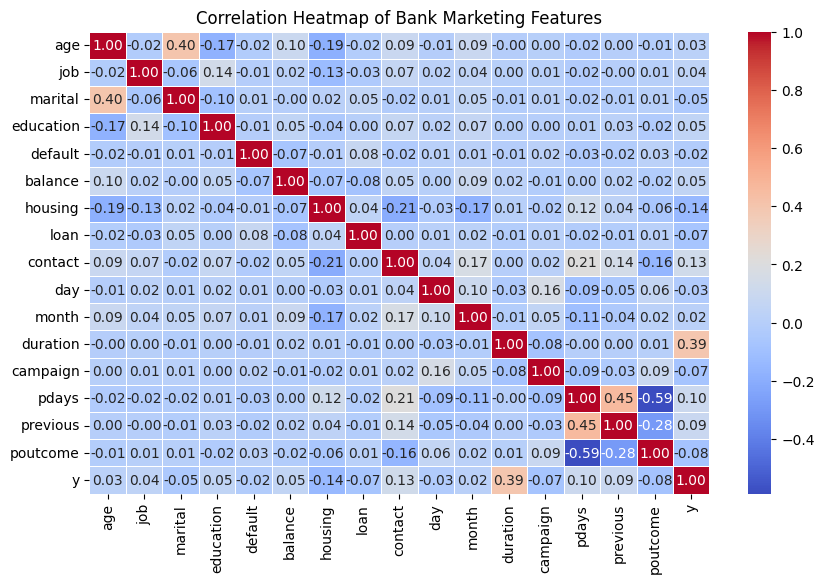

In [ ]:
plt.figure(figsize=(10, 6))

# Set up the correlation matrix
correlation_matrix = bank_full.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Bank Marketing Features")
plt.show()


The correlation heetmap visually represents the relationships between different features in the dataset.

Positively correlated features:

- **Duration vs. Target** → If the call duration is longer, there is a higher likelihood of a successful marketing outcome.

- **Pdays vs. Previous** → If a customer was previously contacted, they are more likely to have a recorded number of days since the last contact.

Negatively correlated features:

- **Age vs. Housing Loan** → Older individuals might be less likely to have a housing loan.

- **Previous vs. Poutcome** → If a customer had more previous contacts, the outcome of those contacts was less likely to be negative.

Key insights:

- Customers with longer call durations are more likely to subscribe.

- Previously contacted customers tend to behave in predictable ways.

- Age and financial commitments influence marketing success.

### Question 8: What challenges did you run into? Do you think it was because of the data, the model, the research question? How would you overcome these challenges? (6pts)

Initially, we were able to develop logistic regression, decision tree, and random forest models with reasonable precision scores; however, we received feedback that given our research question, it would be better to focus on recall as a metric of success. This is because we are interested in the positive class: customers who were responsive to the marketing campaign and did end up purchasing a term deposit with the bank. The goal of the model is to be able to predict the likelihood that a customer will purchase a term deposit; we’re less interested in identifying customers who are unlikely to.

We then reevaluated our initial models and found that our recall scores were low, typically ranging between 30-40%.

In addition to our limited domain knowledge and our revised understanding of the problem, the low recall scores are in part an issue with our dataset. There are significantly more instances of the negative class, customers who did not purchase a term deposit, than the positive class, customers who did.

We addressed these issue using the following methods:
* First, based on feedback from Karim, we did some more intensive hyperparameter tuning for the Decision Tree and the Random Forest models using Grid Search, specifically optimizing for recall scores, then refitted those models with the Optimized Grid Search parameters. This increased the recall scores slightly for both models.
* Second, because there is such an imbalance between the positive and negative classes, we artificially lowered the probability threshold from 0.50 to 0.25 for predicting whether customers would or would not purchase a term deposit. This significantly increased the recall scores for both the Decision Tree and Random Forest models (respectively about 70% and 80%), as they are now more likely to capture the true positives. As stated above, it should be noted that this resulted in reduced precision scores for the positive class in both models, but for the purpose of our research question we are comfortable with this tradeoff.

### Question 9: Explain how your machine learning solution answers the research question you defined. Describe the risks and advantages of applying your solution to unseen data. What are the consequences of your solution being wrong? What are advantages when it is right?  What are some negative and positive societal impacts from your model? (10pts)

While we don’t have access to the exact cost of this telemarketing campaign, our main assumption is that the marketing is done in-house due to the specific nature of this campaign (a Portuguese bank marketing to local customers), as well as the fact that so much data has been collected for a singular banking institution. Generally speaking, it is also possible to outsource a telemarketing campaign to a third party company depending on costs, location of the third party, language needs, etc.

We do not have enough domain knowledge to firmly determine which third party marketing companies a Portuguese banking institution would use (especially seeing as many different Portuguese-speaking telemarketing companies exist in countries around the world, including, unsurprisingly, Portugal, as well). Ultimately, there will be a degree of associated costs per hour.

Since the data set includes around 40,000 people who were contacted over the course of this campaign, it’s likely that the cost per phone call is relatively low.

**Consequences of Incorrect Solution**

The most likely consequences of our solution being wrong include wasted resources in terms of time and money spent contacting clients who are unlikely to respond positively.

In the long term, if the model does not produce accurate predictions, it is likely that customer frustration and annoyance that could damage the bank’s reputation: a lot of people generally do not enjoy being marketed to on their personal phone numbers. There is also the issue of missed opportunities: if the model fails to identify potential customers, then the bank misses out on increased revenue from term deposit subscriptions.

**Advantages of Correct Solution**

If our model is effective, the most immediate advantage is that it allows the bank to identify customers to prioritize for future telemarketing campaigns, reducing time and funds spent on calling customers who are not interested in opening a term deposit, and ideally increasing revenue from increased term deposit account openings.

**Societal Impacts**

The social impacts of the campaign would include possible economic growth (although that would have to be analyzed separately), as well as more personalized campaigns that better understand the needs of customers in this banking institution.

That said, any future campaigns must consider customer privacy as a factor, especially if customers are unaware of how their data is being used. Similarly, certain demographics might be favored over others in the model. In general, with using this sort of dataset, there should be precautions taken (e.g. anonymization) to protect sensitive customer information.

### Question 10: Name one research question you might ask next for future work (don’t worry, you don’t have to do it!) Why is it important? (3pts)

A future question could be: "Can we develop a predictive model to identify the most promising customers for future marketing campaigns based on their past interactions and demographic characteristics?"

Exploring this question would provide financial institutions with actionable insights to refine their outreach strategies and optimize business outcomes. By leveraging historical customer data, a predictive model could help financial institutions to save resources by targeting customers who are more likely to subscribe, reducing unnecessary calls and marketing efforts. Insights from the model can also help tailor marketing strategies based on customer behaviors and characteristics.

### Question 11: Model Card

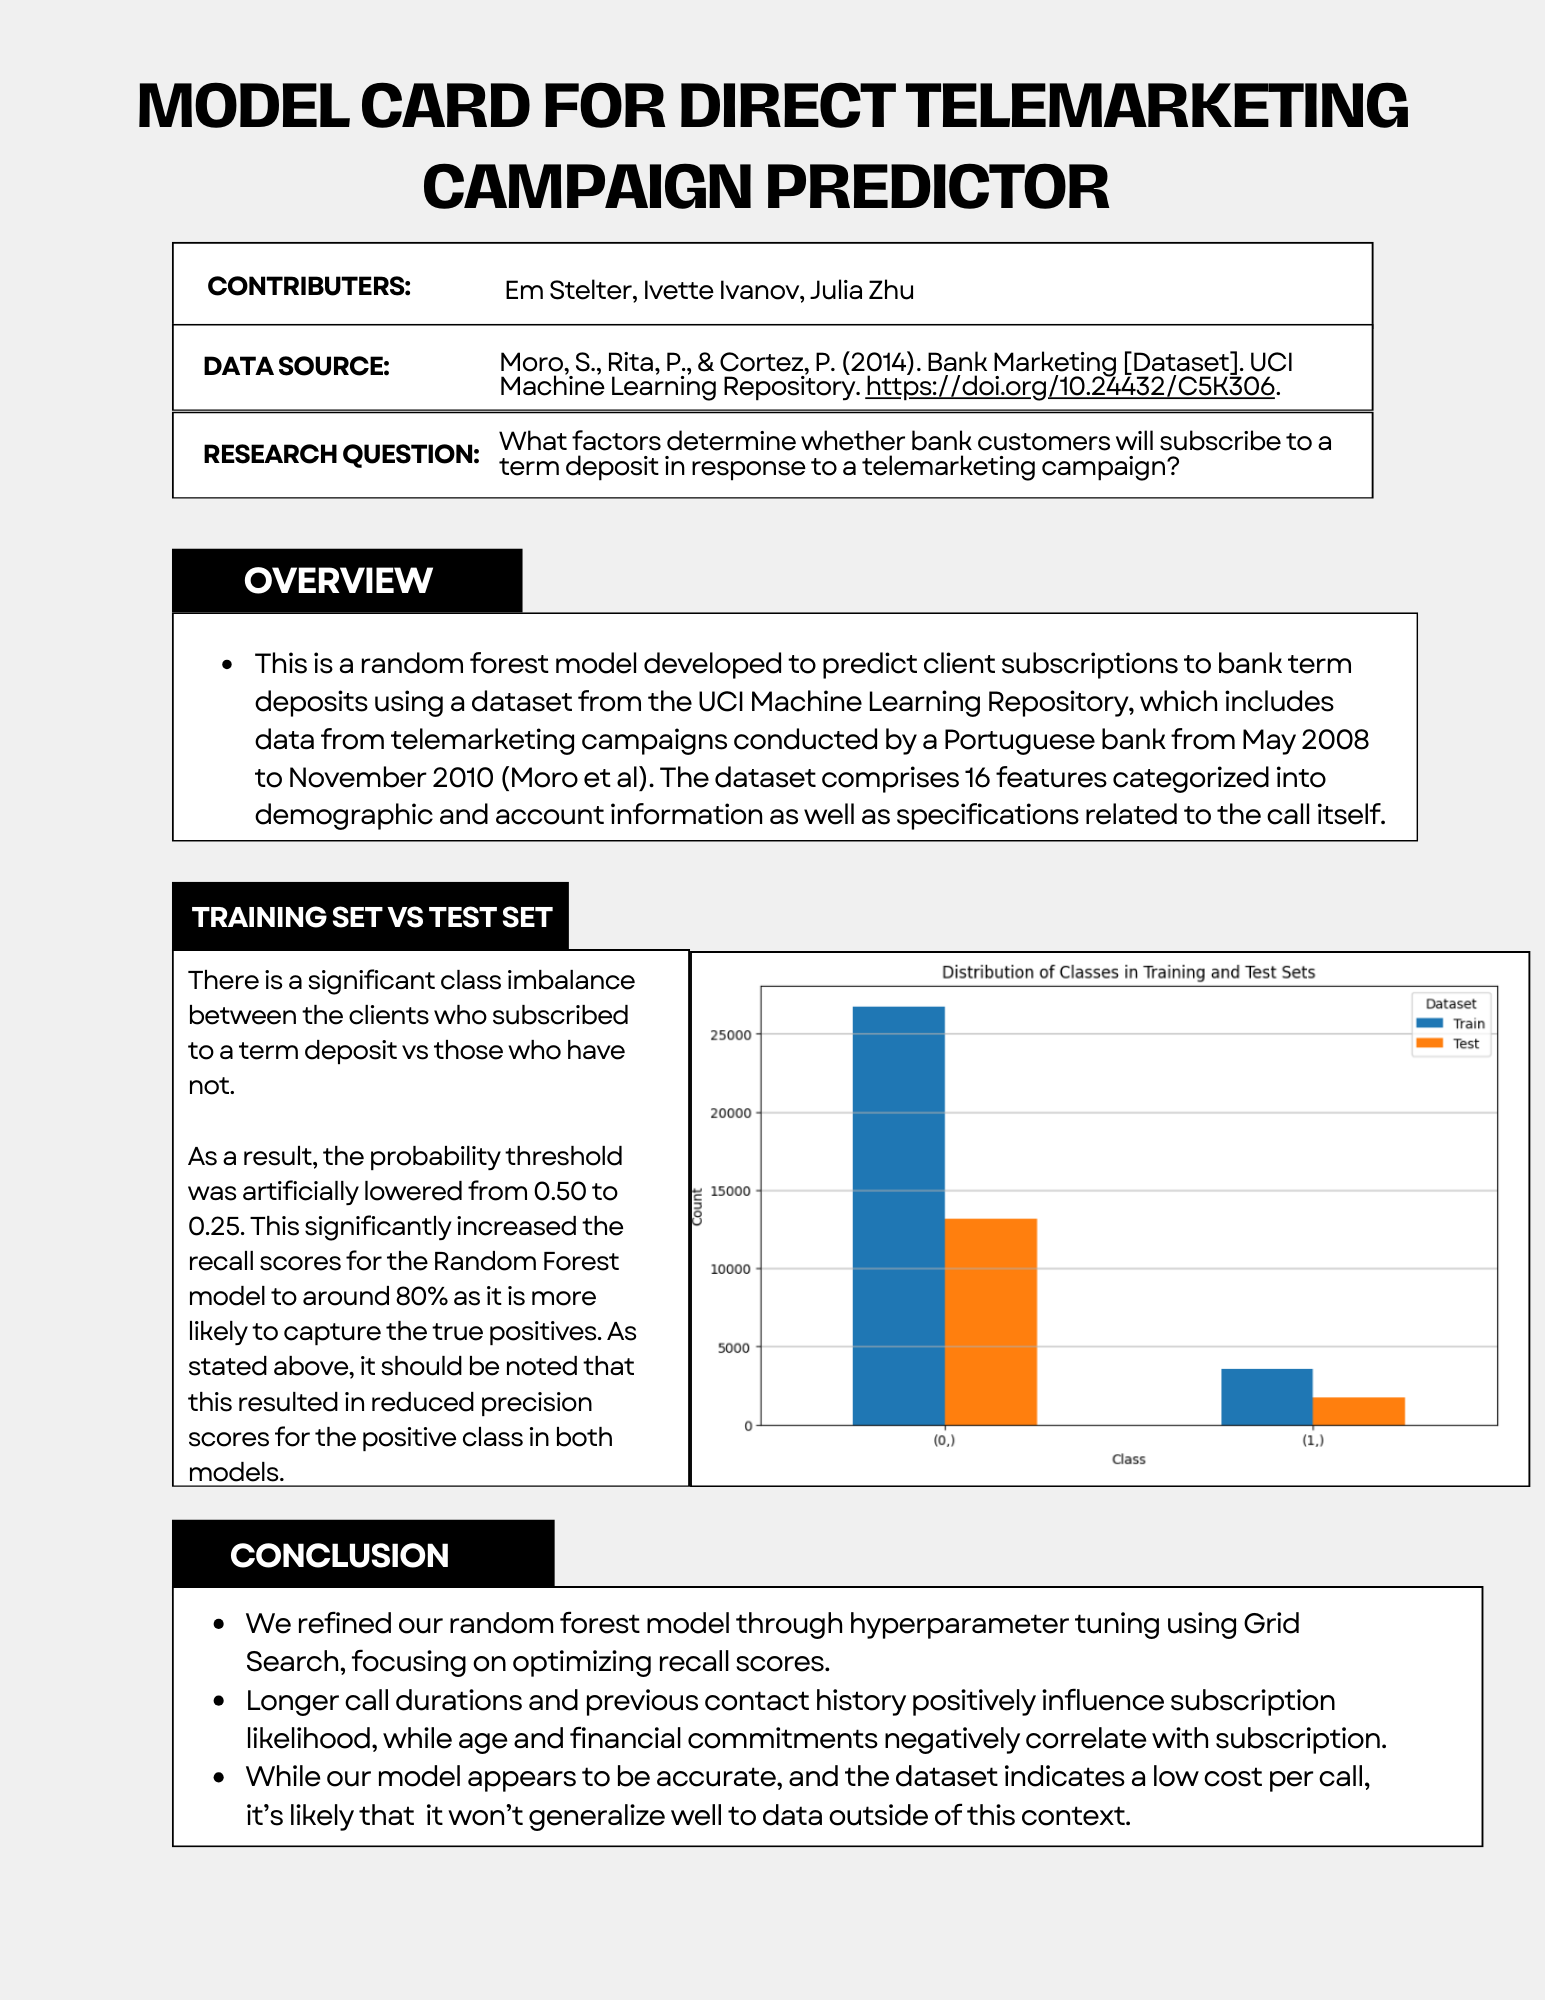

# References

* Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306.

* “Term Deposit: Definition, How It’s Used, Rates, and How to Invest.” Investopedia, https://www.investopedia.com/terms/t/termdeposit.asp.  Accessed 28 Feb. 2025.

# Appendix A: Exploratory Data Analysis

In [ ]:
# exploratory data analysis for feature selection for Decision Tree model

# Summarize data
print(bank_full.describe())

In [ ]:
# Correlation heat map (code example from: https://www.geeksforgeeks.org/how-to-create-a-seaborn-correlation-heatmap-in-python/)

# Import modules
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

# Plotting correlation heatmap
bank_full_heatmap = sb.heatmap(bank_full.corr(numeric_only=True))

# Displaying heatmap
plt.show()

# Okay, so the variables that seem to be more correlated are:

# Positively correlated:
# - Age and marital (positively correlated)
# - Duration and y/target/success of marketing campaign
# - pdays and previous

# Negatively correlated:
# - pdays and poutcome (strongly negatively correlated)
# - Age and education (slightly negatively correlated)
# - Age and housing (slightly negatively correlated)
# - Housing and month (negatively correlated)
# - Housing and contact (negatively correlated)
# - previous and poutcome (strongly negatively correlated)

Selected features from EDA process include:
- duration
- housing
- pdays
- month
- poutcome
- age

# Appendix B: Decision Tree Model

### Initial Decision Tree Model

In [ ]:
# Select features based on exploratory data analysis
X_bank_full_V3 = bank_full[['age','housing','month','duration','pdays','poutcome']]
y_bank_full_V3 = bank_full[['y']]

In [ ]:
# Divide dataset into training and test sets -- adjusting to 20% test set
from sklearn.model_selection import train_test_split
X_train_V3, X_test_V3, y_train_V3, y_test_V3 = train_test_split(X_bank_full_V3, y_bank_full_V3, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# Conduct grid search
from sklearn.model_selection import GridSearchCV
parameters = {'max_depth':list(range(1,30,2)), 'min_samples_split':list(range(2,30,2)), 'min_samples_leaf':list(range(2,20,2))}
tree_v6 = GridSearchCV(tree_v1, param_grid=parameters, scoring='recall')
tree_v6.fit(X_train_V3, y_train_V3)
sorted(tree_v6.cv_results_.keys())

['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'param_max_depth',
 'param_min_samples_leaf',
 'param_min_samples_split',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score']

In [ ]:
# Convert gridsearch results to dataframe
tree_v6_gridsearch_results = pd.DataFrame(tree_v6.cv_results_)

In [ ]:
# Display gridsearch results
from IPython.display import display
import pandas as pd
display(tree_v6_gridsearch_results)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.015207,0.002058,0.009343,0.000488,1,2,2,"{'max_depth': 1, 'min_samples_leaf': 2, 'min_s...",0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1765
1,0.013106,0.000611,0.008292,0.000361,1,2,4,"{'max_depth': 1, 'min_samples_leaf': 2, 'min_s...",0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1765
2,0.012404,0.000651,0.008365,0.000598,1,2,6,"{'max_depth': 1, 'min_samples_leaf': 2, 'min_s...",0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1765
3,0.012417,0.000594,0.008205,0.000241,1,2,8,"{'max_depth': 1, 'min_samples_leaf': 2, 'min_s...",0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1765
4,0.012358,0.000626,0.009022,0.001398,1,2,10,"{'max_depth': 1, 'min_samples_leaf': 2, 'min_s...",0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,0.071243,0.001963,0.010478,0.000744,29,18,20,"{'max_depth': 29, 'min_samples_leaf': 18, 'min...",0.394799,0.364066,0.415584,0.41253,0.444444,0.406285,0.026442,1025
1886,0.072514,0.004823,0.009847,0.000230,29,18,22,"{'max_depth': 29, 'min_samples_leaf': 18, 'min...",0.394799,0.364066,0.415584,0.41253,0.444444,0.406285,0.026442,1025
1887,0.069448,0.002591,0.009038,0.000361,29,18,24,"{'max_depth': 29, 'min_samples_leaf': 18, 'min...",0.394799,0.364066,0.415584,0.41253,0.444444,0.406285,0.026442,1025
1888,0.068433,0.001149,0.009264,0.000310,29,18,26,"{'max_depth': 29, 'min_samples_leaf': 18, 'min...",0.394799,0.364066,0.415584,0.41253,0.444444,0.406285,0.026442,1025


In [ ]:
# Identify gridsearch result with best mean recall score
tree_v6_gridsearch_results.iloc[tree_v6_gridsearch_results['rank_test_score'].idxmin()]

# Appears to be max_depth=17 and min_samples_split = 2, and min_samples_leaf=24 with 43% mean recall score
print(tree_v6_gridsearch_results.iloc[tree_v6_gridsearch_results['rank_test_score'].idxmin()])

mean_fit_time                                                       0.080381
std_fit_time                                                        0.005857
mean_score_time                                                     0.009016
std_score_time                                                      0.000081
param_max_depth                                                           17
param_min_samples_leaf                                                     2
param_min_samples_split                                                   24
params                     {'max_depth': 17, 'min_samples_leaf': 2, 'min_...
split0_test_score                                                   0.437352
split1_test_score                                                   0.381797
split2_test_score                                                   0.416765
split3_test_score                                                   0.445626
split4_test_score                                                   0.473995

In [ ]:
# Fit Decision Tree model
from sklearn.tree import DecisionTreeClassifier
tree_v6 = DecisionTreeClassifier(random_state=42, max_depth=17, min_samples_split=2, min_samples_leaf=24, criterion='gini')
tree_v6.fit(X_train_V3, y_train_V3)

DecisionTreeClassifier(max_depth=17, min_samples_leaf=24, random_state=42)

In [ ]:
# Run predictions for Decision Tree model with grid search parameters
y_pred_tree_v6 = tree_v6.predict(X_test_V3)

from sklearn.metrics import classification_report
print(classification_report(y_test_V3, y_pred_tree_v6))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      7985
           1       0.59      0.42      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.69      0.71      9043
weighted avg       0.89      0.90      0.89      9043



### Decision Tree_Lower Decision Threshold

In [ ]:
# Set lower decision threshold
from sklearn.model_selection import FixedThresholdClassifier
tree_v6_lower_threshold = FixedThresholdClassifier(tree_v6, threshold=0.25, response_method="predict_proba").fit(X_train_V3, y_train_V3)

In [ ]:
# Run predictions for decision tree with lowered threshold
y_pred_tree_lthresh = tree_v6_lower_threshold.predict(X_test_V3)

print(classification_report(y_test_V3, y_pred_tree_lthresh))

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      7985
           1       0.46      0.70      0.56      1058

    accuracy                           0.87      9043
   macro avg       0.71      0.80      0.74      9043
weighted avg       0.90      0.87      0.88      9043



###  Alternative Undersampling Method used with a Decision Tree Model & Viewing the Class Imbalance

(Likely to underfit on unseen data, but did improve the recall score, we wanted to include it as a possible alternative method that uses fewer resources).

In [ ]:
# Convert the training data to a 1D array because it wasn't working otherwise
if y_train_V3.ndim == 2:
    y_train_V3 = y_train_V3.values.ravel()

# check out how many postives there are verus negatives
class_distribution = pd.Series(y_train_V3).value_counts()
print(class_distribution)

0    31937
1     4231
Name: count, dtype: int64


In [ ]:
# Try undersampling to have a better class balance

# https://www.geeksforgeeks.org/introduction-to-upsampling-and-downsampling-imbalanced-data-in-python/
# https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)

# Fit and resample the training data
X_resampled, y_resampled = undersampler.fit_resample(X_train_V3, y_train_V3)

# Print out the new class distribution
new_class_distribution = pd.Series(y_resampled).value_counts()
print(new_class_distribution)

0    4231
1    4231
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and validation sets
X_train_under, X_val_under, y_train_under, y_val_under = train_test_split(X_train_V3, y_train_V3, test_size=0.2, random_state=42, stratify=y_train_V3)

# Check the class distribution in the training and validation sets- see if it's as extreme as it was previously
print("Training set class distribution:")
print(pd.Series(y_train_under).value_counts())

print("Validation set class distribution:")
print(pd.Series(y_val_under).value_counts())


Training set class distribution:
0    25549
1     3385
Name: count, dtype: int64
Validation set class distribution:
0    6388
1     846
Name: count, dtype: int64


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create and train a new decision tree model
tree_v7 = DecisionTreeClassifier(random_state=42, max_depth=17, min_samples_split=2, min_samples_leaf=24, criterion='gini')
tree_v7.fit(X_resampled, y_resampled)

DecisionTreeClassifier(max_depth=17, min_samples_leaf=24, random_state=42)

In [ ]:
# Make predictions on the validation set
y_pred_val = tree_v7.predict(X_val_under)

from sklearn.metrics import classification_report

# Evaluate the model's performance
print("Classification report for validation set:")
print(classification_report(y_val_under, y_pred_val))

Classification report for validation set:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89      6388
           1       0.38      0.87      0.53       846

    accuracy                           0.82      7234
   macro avg       0.68      0.84      0.71      7234
weighted avg       0.91      0.82      0.85      7234

